
STAGE 1 - LOAD PRE-MERGE DATA AND REMOVE FALSE FUZZY MERGE
Rows loaded (pre-merge, 742-row file) : 741

Analytical dataset : N = 741 universities
Total cyber events : 10265
Countries          : 67

STAGE 2 - DESCRIPTIVE STATISTICS (TABLE 2)
             Variable   N      Mean         SD  Min  Median         Max
cyber_news_count (DV) 741     13.85      17.78    3       7         155
  cited_by_count (IV) 741 6,050,000 12,696,725   93 867,170 143,061,250
   log_cited_by_count 741     13.23       2.95 4.54   13.67       18.78

Overdispersion ratio (var/mean) : 22.81  -> Negative Binomial justified
Skewness raw citations          : 4.35
Skewness log citations          : -0.55

STAGE 3 - GEOGRAPHIC DISTRIBUTION (FIGURE 8)
country
US    385
GB     70
CA     30
AU     24
IN     24
IT     22
IL     12
NL     12
DE     10
CN      9

US: 385 (52.0%)   GB: 70 (9.4%)


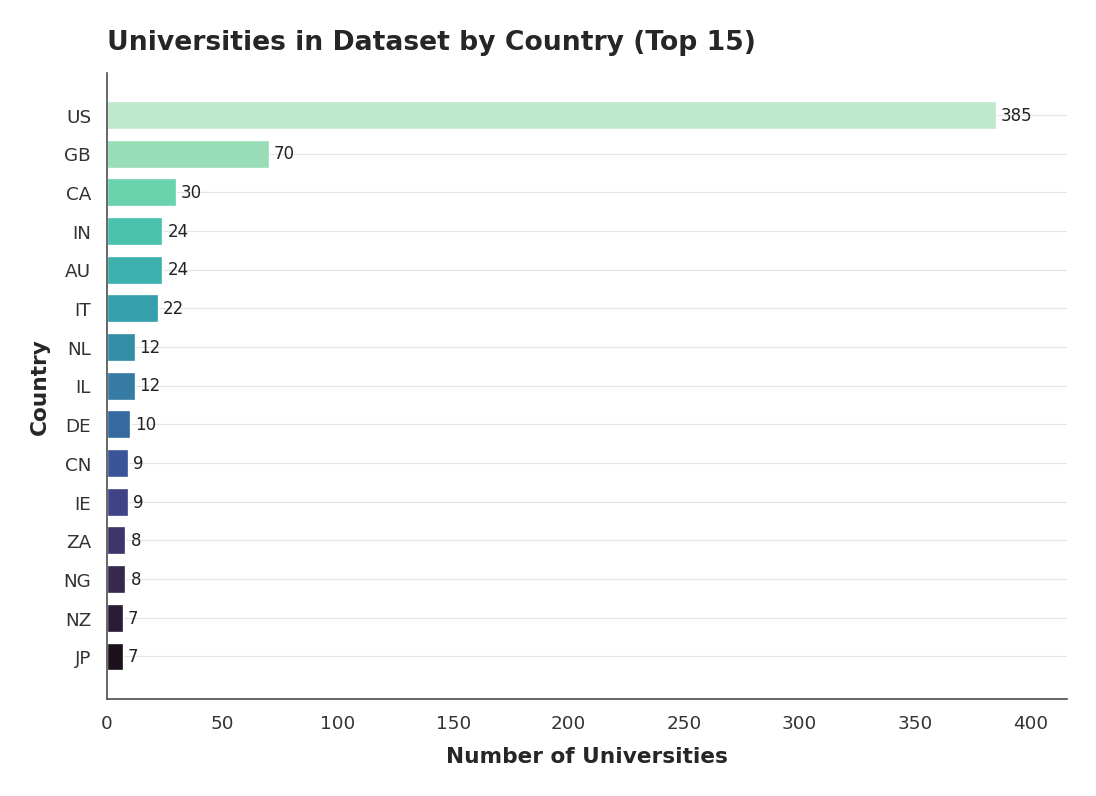


STAGE 4 - TOP UNIVERSITIES (TABLE 3 / FIGURE 2)
                                      the_official_name country  cyber_news_count  cited_by_count
1                                  University of Oxford      GB               155        62747514
2   Indiana University – Purdue University Indianapolis      US               133        13891482
3                                   Stanford University      US               120        86691256
4                    University of California, Berkeley      US               111        55909022
5                                   Columbia University      US               101        46977923
6                                University of Michigan      US               101        65924778
7                                  University of Surrey      GB               101         4132517
8                                 Georgetown University      US                99         8833057
9                                    Harvard University      US      

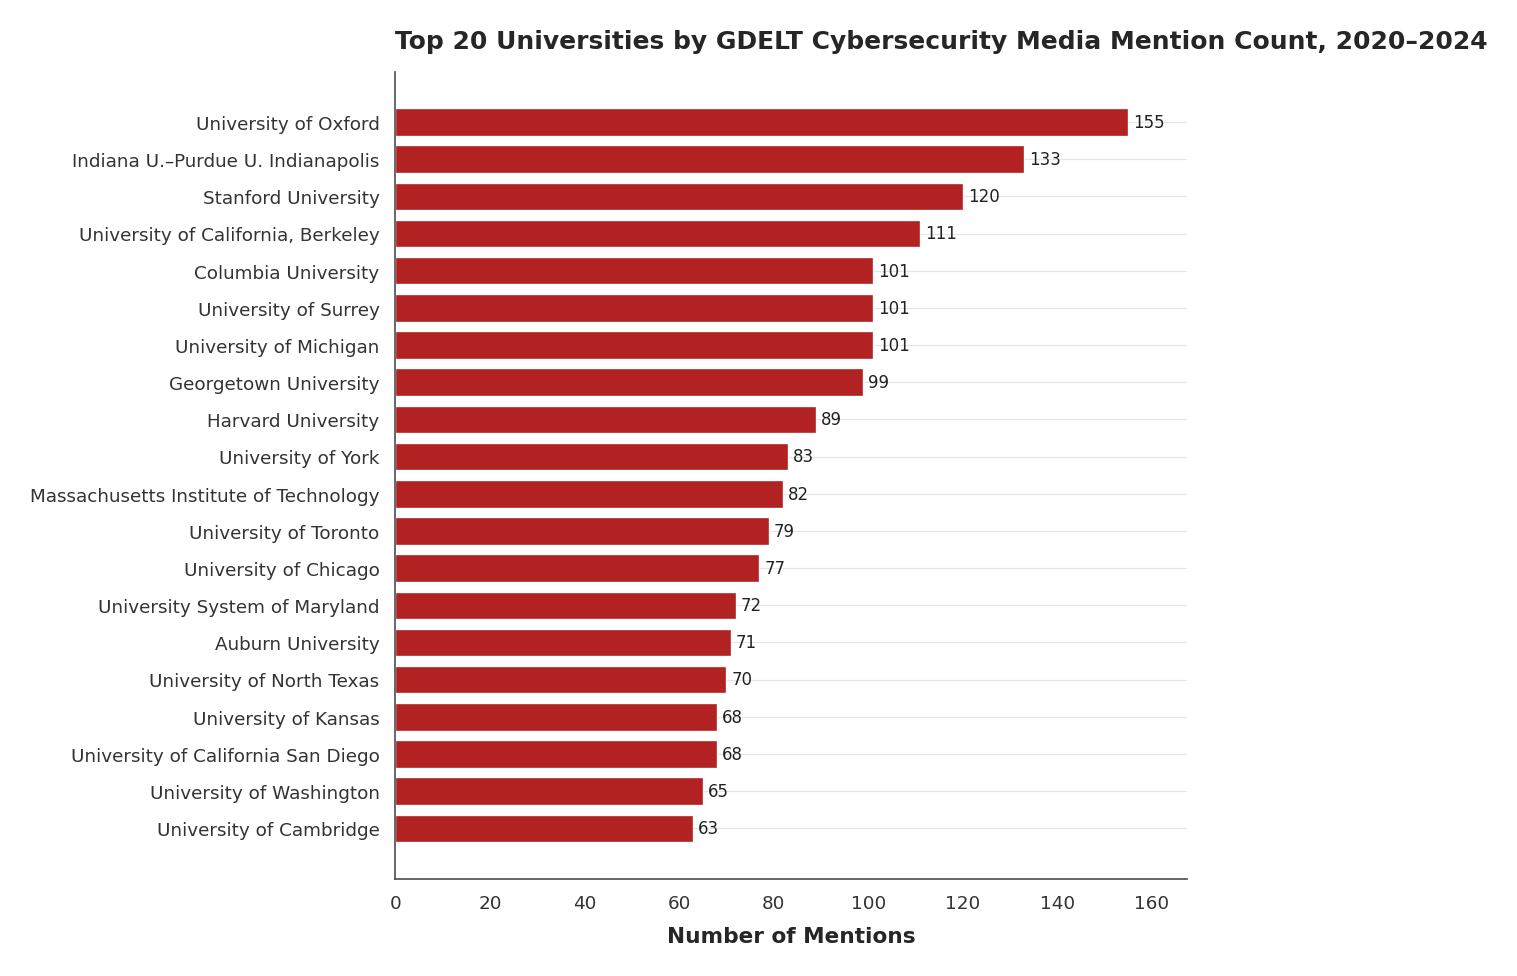


STAGE 5 - PRESTIGE TIER ANALYSIS (TABLE 4 / FIGURES 5 & 10)
                  count   mean  median   pct
prestige_tier                               
Elite (5M+)         207  26.05    18.0  27.9
High (1M-5M)        148  13.32     9.0  20.0
Medium (100K-1M)    184   8.00     6.0  24.8
Low (<100K)         202   7.07     5.0  27.3

Tier count sum = 741 (must equal 741)


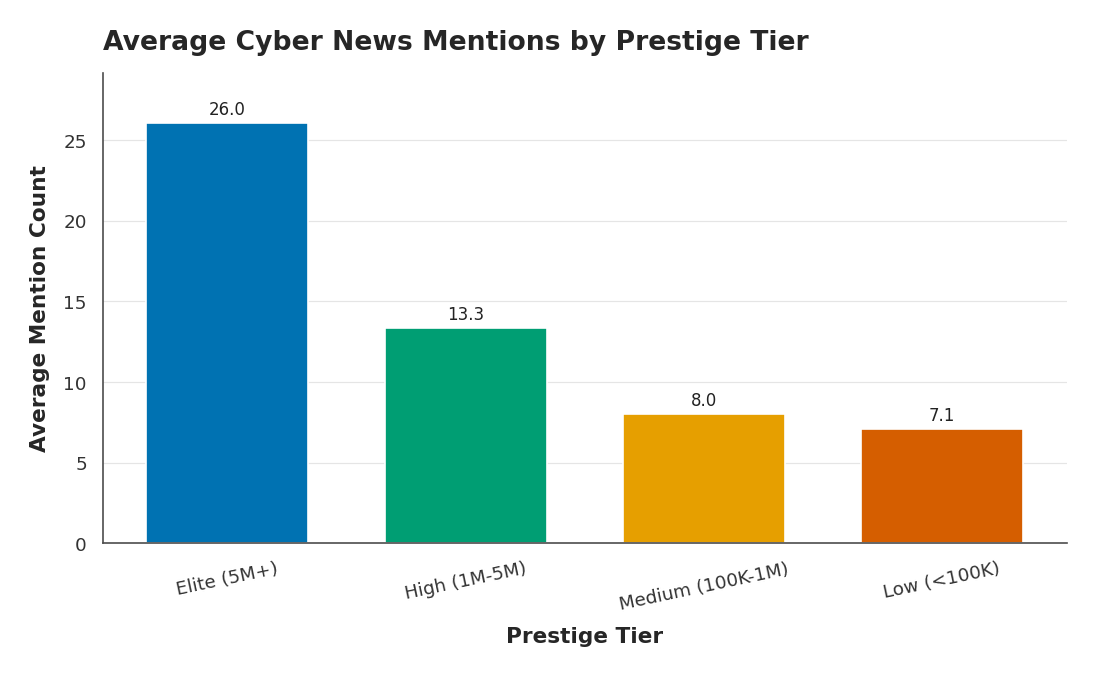

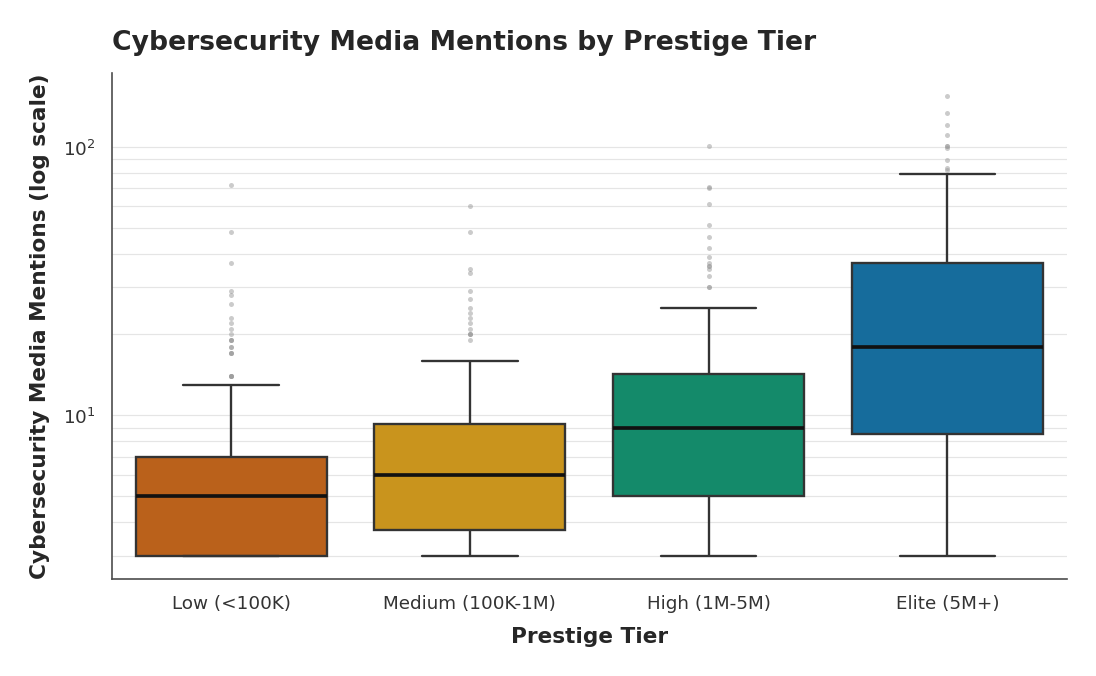


STAGE 6 - IV DISTRIBUTION AND CORRELATIONS (FIGURES 3, 4, 6)


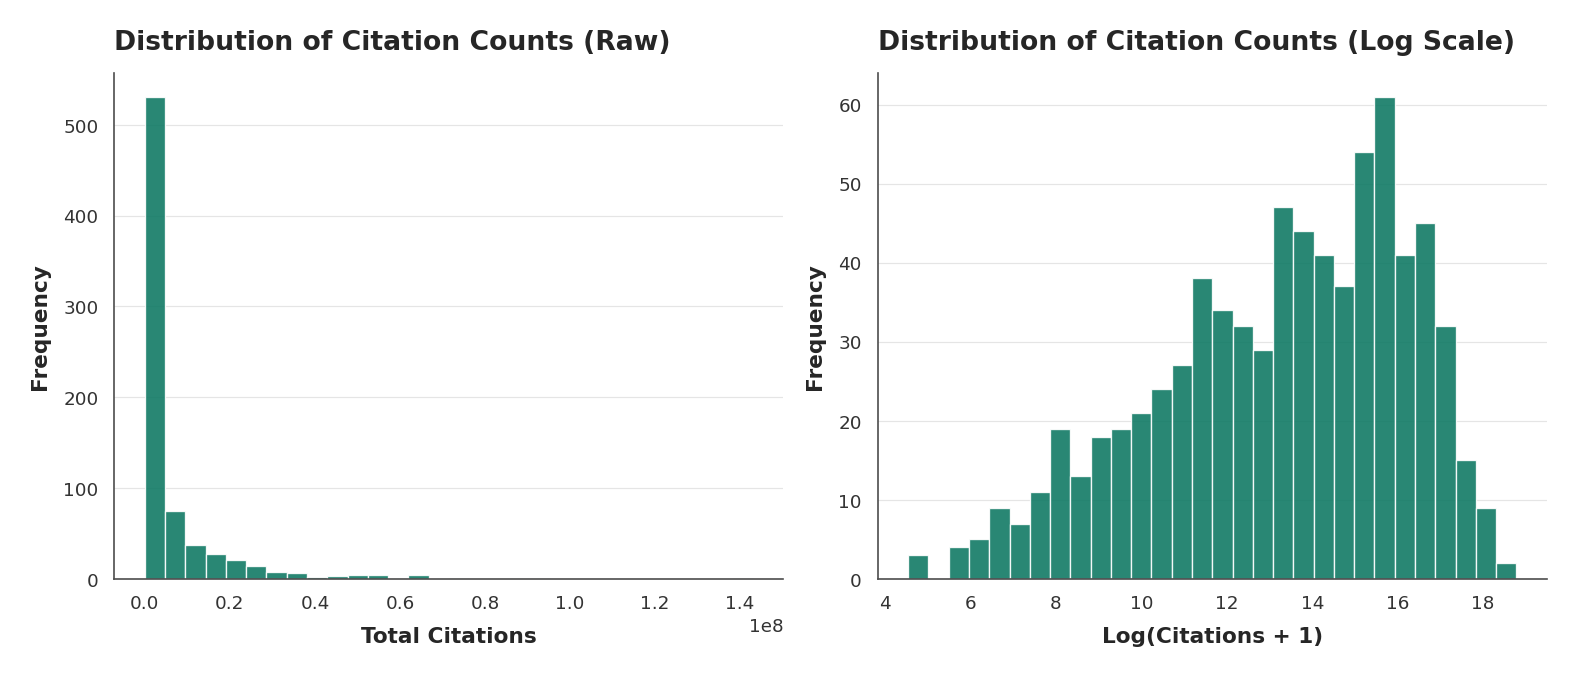

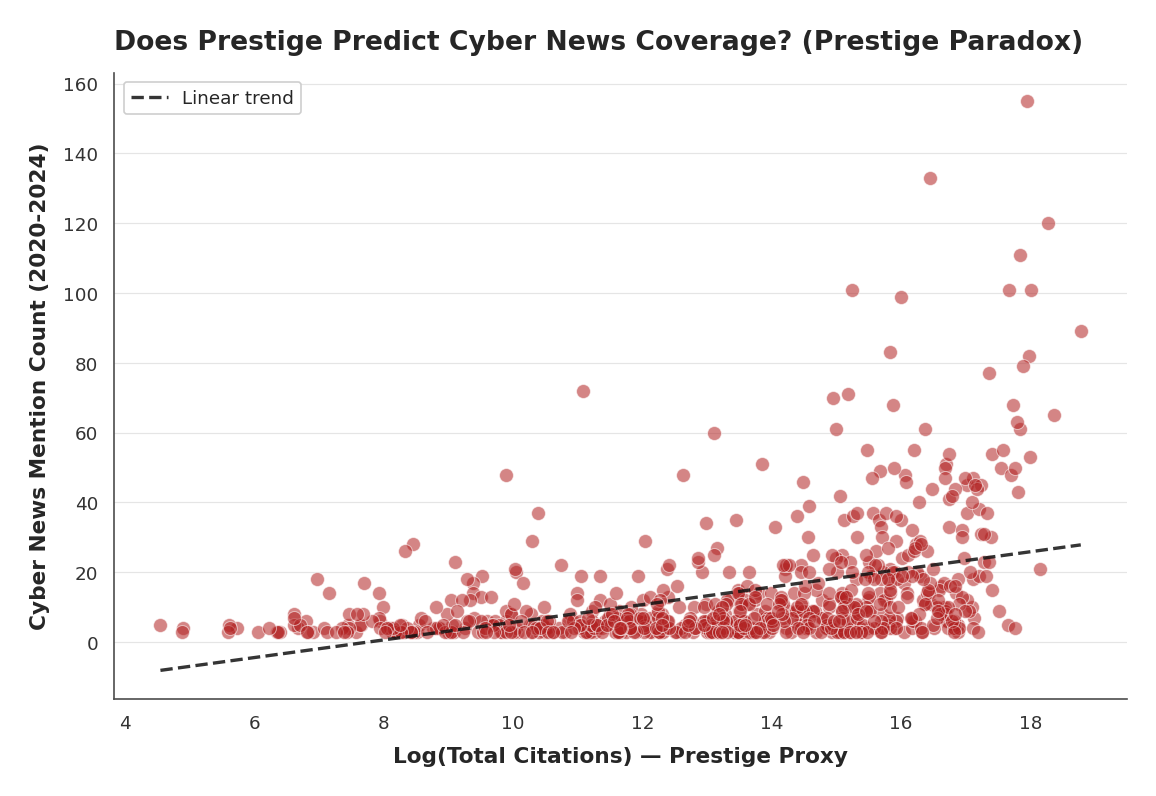

                    cyber_news_count  log_cited_by_count  log_works_count
cyber_news_count               1.000               0.419            0.404
log_cited_by_count             0.419               1.000            0.985
log_works_count                0.404               0.985            1.000

r(log_cited_by_count, log_works_count) = 0.985  <- collinearity


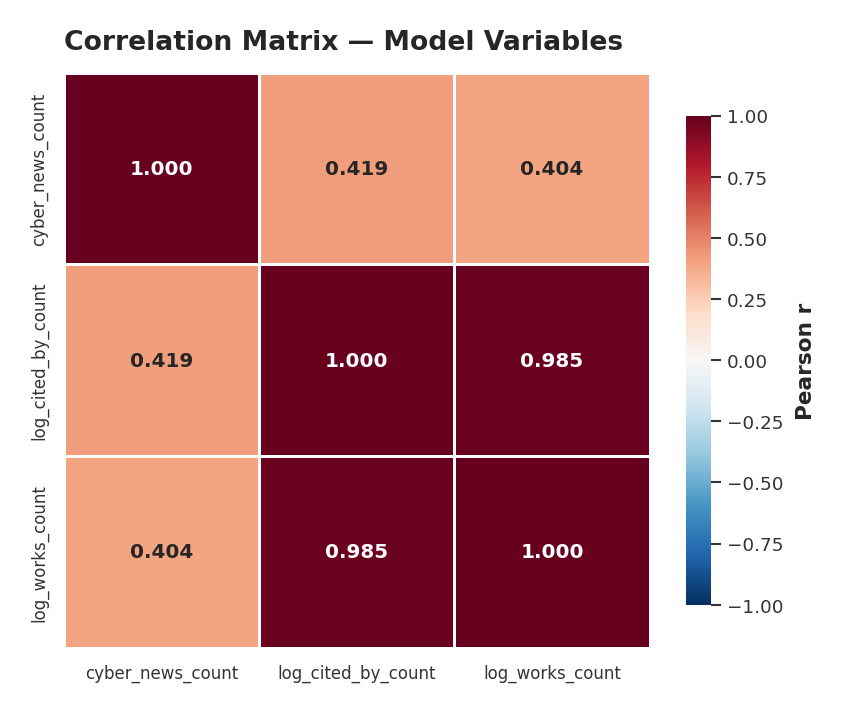


STAGE 7 - CHI-SQUARE TEST (REPORTED FOR TRANSPARENCY ONLY)
has_event       Yes
prestige_group     
High            371
Low             370

chi2 = 0.0, p = 1.0
Uninformative by construction: the 3+ frequency filter means every
university has events, so has_event has no variation.

STAGE 8 - NEGATIVE BINOMIAL REGRESSION (TABLE 5)
Countries in data      : 67
Countries with >= 5 unis : 20  (rest pooled as 'Other')
Country groups         : 21
Country dummies        : 20
Reference category     : AE (alphabetically first)

                     NegativeBinomial Regression Results                      
Dep. Variable:       cyber_news_count   No. Observations:                  741
Model:               NegativeBinomial   Df Residuals:                      719
Method:                           MLE   Df Model:                           21
Date:                Wed, 29 Jul 2026   Pseudo R-squ.:                 0.07499
Time:                        14:08:00   Log-Likelihood:                -2503.6
co

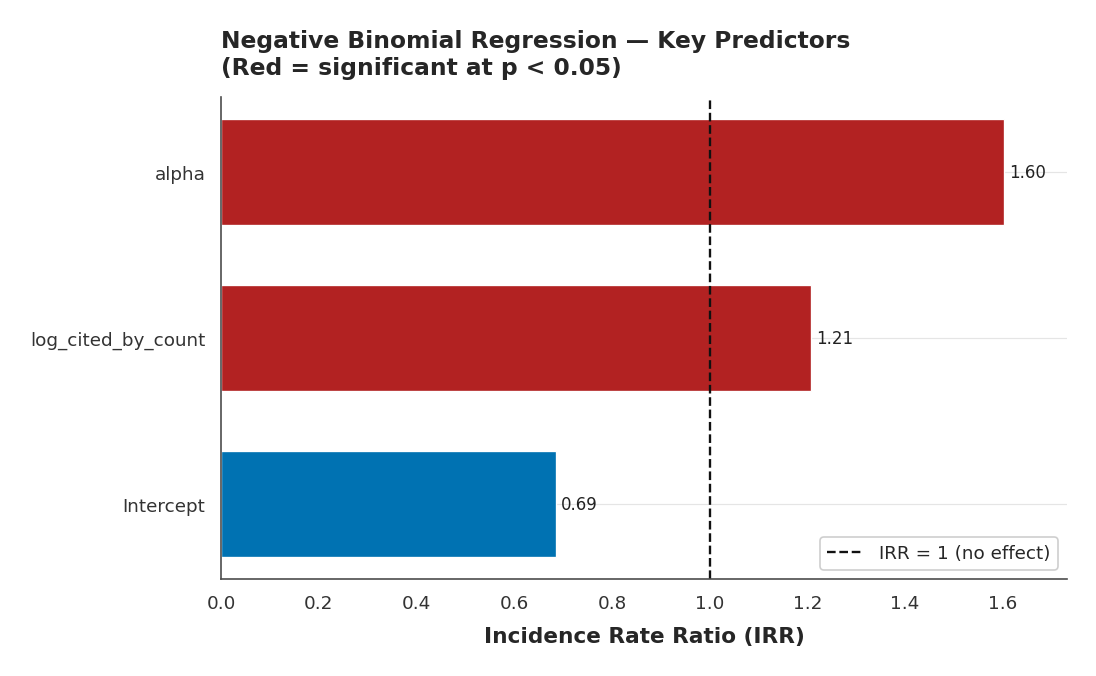


STAGE 9 - OPTIMISER STABILITY (TABLE 6)
bfgs     | converged=True  | coef=0.1882 | SE=0.0096 | p=0.000000 | IRR=1.2071
lbfgs    | converged=True  | coef=0.1883 | SE=0.0096 | p=0.000000 | IRR=1.2072
powell   | converged=True  | coef=0.1883 | SE=0.0096 | p=0.000000 | IRR=1.2072
cg       | converged=True  | coef=0.1882 | SE=0.0096 | p=0.000000 | IRR=1.2071
nm       | converged=False | coef=0.1928 | SE=0.0096 | p=0.000000 | IRR=1.2127

Converged: 4/5 | coef 0.1882-0.1883 | IRR 1.2071-1.2072

STAGE 10 - ROBUSTNESS CHECK WITH log_works_count (TABLE 7)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.3092      0.349     -0.886      0.376      -0.993       0.375
C(country_grouped)[T.AU]        0.2395      0.359      0.667      0.505      -0.464       0.943
C(country_grouped)[T.CA]        0.1208      0.353      0.342   

In [1]:
"""
================================================================================
THE PRESTIGE PARADOX: Institutional Bibliometric Status and Cybersecurity
Media Salience in Global Higher Education, 2020-2024
================================================================================
Author      : Shreyansh Chaudhary (Student ID: 001487390)
Programme   : MSc Business Analytics, University of Greenwich
Module      : BUSI 1783 - Business Analytics Project
Supervisor  : Dr Raunak Mishra

Figures are saved as PNGs AND displayed inline in the output cell.
================================================================================
"""

import json
import os
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency, skew

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------ config ---
RAW_INPUT   = "/content/prestige_paradox_dataset_741.csv"
FINAL_CSV   = "/content/prestige_paradox_dataset_741.csv"
MANIFEST    = "results_manifest.json"
FIG_DIR     = "figures"
FALSE_MERGE = "He University"      # identified via manual validation
MIN_COUNTRY = 5                    # countries with < 5 unis pooled into 'Other'

os.makedirs(FIG_DIR, exist_ok=True)
M = {}   # results manifest

def rule(t):
    print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)


# =========================================================== VISUAL THEME ===
# Centralised, publication-quality styling. This block changes ONLY the visual
# appearance of figures. It does not touch any data, calculation, model, or
# printed statistic. A single palette and rcParams set is applied so all 11
# figures are visually consistent and export cleanly at 300 DPI.

# Colour-blind-friendly qualitative palette (Okabe-Ito derived) plus a set of
# named roles reused across figures for consistency.
PALETTE = {
    "blue":    "#0072B2",
    "orange":  "#E69F00",
    "green":   "#009E73",
    "red":     "#B22222",
    "purple":  "#5D3A9B",
    "teal":    "#117A65",
    "grey":    "#7F7F7F",
    "gold":    "#D4A017",
}
SEQ_CMAP  = "mako"       # perceptually uniform sequential colormap
HEAT_CMAP = "RdBu_r"     # diverging, colour-blind safe for correlation matrices

# Consistent tier colours (used in both the tier bar chart and the boxplot).
TIER_COLORS = {
    "Low (<100K)":      "#D55E00",
    "Medium (100K-1M)": "#E69F00",
    "High (1M-5M)":     "#009E73",
    "Elite (5M+)":      "#0072B2",
}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "savefig.facecolor":  "white",
    "figure.dpi":         120,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.25,
    "font.family":        "DejaVu Sans",
    "font.size":          12,
    "axes.titlesize":     16,
    "axes.titleweight":   "bold",
    "axes.titlepad":      14,
    "axes.labelsize":     13,
    "axes.labelweight":   "bold",
    "axes.labelpad":      8,
    "axes.edgecolor":     "#4D4D4D",
    "axes.linewidth":     1.0,
    "axes.grid":          True,
    "grid.color":         "#CCCCCC",
    "grid.linewidth":     0.7,
    "grid.alpha":         0.5,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "xtick.color":        "#333333",
    "ytick.color":        "#333333",
    "legend.fontsize":    11,
    "legend.title_fontsize": 12,
    "legend.frameon":     True,
    "legend.framealpha":  0.95,
    "legend.edgecolor":   "#CCCCCC",
    "legend.fancybox":    True,
})

def _style_axes(ax):
    """Trim chart junk: drop top/right spines, soften remaining spines,
    keep only a light horizontal grid. Purely cosmetic."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#4D4D4D")
    ax.grid(axis="x", alpha=0.0)
    ax.grid(axis="y", color="#CCCCCC", linewidth=0.7, alpha=0.5)
    ax.set_axisbelow(True)

def _label_barh(ax, fmt="{:,.0f}", pad=3, size=10):
    """Add clean value labels to the ends of horizontal bars."""
    xmax = 0
    for p in ax.patches:
        xmax = max(xmax, p.get_width())
    for p in ax.patches:
        w = p.get_width()
        ax.annotate(fmt.format(w),
                    xy=(w, p.get_y() + p.get_height() / 2),
                    xytext=(pad, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=size, color="#222222")
    ax.set_xlim(right=xmax * 1.08)

def _label_barv(ax, fmt="{:,.1f}", pad=3, size=10):
    """Add clean value labels to the tops of vertical bars."""
    ymax = 0
    for p in ax.patches:
        ymax = max(ymax, p.get_height())
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(fmt.format(h),
                    xy=(p.get_x() + p.get_width() / 2, h),
                    xytext=(0, pad), textcoords="offset points",
                    va="bottom", ha="center", fontsize=size, color="#222222")
    ax.set_ylim(top=ymax * 1.12)


# =============================================================== STAGE 1 =====
rule("STAGE 1 - LOAD PRE-MERGE DATA AND REMOVE FALSE FUZZY MERGE")

raw = pd.read_csv(RAW_INPUT)
print(f"Rows loaded (pre-merge, 742-row file) : {len(raw)}")

he = raw[raw["the_official_name"] == FALSE_MERGE]
if len(he):
    print(f"\nFalse merge found: '{FALSE_MERGE}'")
    print(f"  events attributed  : {int(he['cyber_news_count'].iloc[0])}")
    print(f"  GDELT names merged : {he['gdelt_name'].iloc[0][:90]}...")
    print("  -> removing (unrelated fragments collapsed onto one OpenAlex record)")

df = raw[raw["the_official_name"] != FALSE_MERGE].copy().reset_index(drop=True)

M["n_universities_pre_merge_file"] = int(len(raw))
M["he_university_events_removed"]  = int(he["cyber_news_count"].iloc[0]) if len(he) else 0
M["n_universities"]                = int(len(df))
M["total_cyber_events"]            = int(df["cyber_news_count"].sum())
M["n_countries"]                   = int(df["country"].nunique())

print(f"\nAnalytical dataset : N = {M['n_universities']} universities")
print(f"Total cyber events : {M['total_cyber_events']}")
print(f"Countries          : {M['n_countries']}")


# =============================================================== STAGE 2 =====
rule("STAGE 2 - DESCRIPTIVE STATISTICS (TABLE 2)")

dv = df["cyber_news_count"]
M["dv_mean"]     = round(float(dv.mean()), 2)
M["dv_sd"]       = round(float(dv.std()), 2)
M["dv_var"]      = round(float(dv.var()), 2)
M["dv_min"]      = int(dv.min())
M["dv_median"]   = int(dv.median())
M["dv_max"]      = int(dv.max())
M["overdispersion_ratio"] = round(float(dv.var() / dv.mean()), 2)
M["dv_max_university"] = str(df.loc[dv.idxmax(), "the_official_name"])

iv = df["cited_by_count"]
M["iv_mean"]   = int(round(iv.mean()))
M["iv_sd"]     = int(round(iv.std()))
M["iv_min"]    = int(iv.min())
M["iv_median"] = int(round(iv.median()))
M["iv_max"]    = int(iv.max())

lg = df["log_cited_by_count"]
M["log_iv_mean"]   = round(float(lg.mean()), 2)
M["log_iv_sd"]     = round(float(lg.std()), 2)
M["log_iv_min"]    = round(float(lg.min()), 2)
M["log_iv_median"] = round(float(lg.median()), 2)
M["log_iv_max"]    = round(float(lg.max()), 2)

M["skew_raw_citations"] = round(float(skew(iv)), 2)
M["skew_log_citations"] = round(float(skew(lg)), 2)

t2 = pd.DataFrame([
    ["cyber_news_count (DV)", M["n_universities"], f"{M['dv_mean']:.2f}", f"{M['dv_sd']:.2f}",
     M["dv_min"], M["dv_median"], M["dv_max"]],
    ["cited_by_count (IV)", M["n_universities"], f"{M['iv_mean']:,}", f"{M['iv_sd']:,}",
     f"{M['iv_min']:,}", f"{M['iv_median']:,}", f"{M['iv_max']:,}"],
    ["log_cited_by_count", M["n_universities"], f"{M['log_iv_mean']:.2f}", f"{M['log_iv_sd']:.2f}",
     f"{M['log_iv_min']:.2f}", f"{M['log_iv_median']:.2f}", f"{M['log_iv_max']:.2f}"],
], columns=["Variable", "N", "Mean", "SD", "Min", "Median", "Max"])
print(t2.to_string(index=False))

print(f"\nOverdispersion ratio (var/mean) : {M['overdispersion_ratio']}  -> Negative Binomial justified")
print(f"Skewness raw citations          : {M['skew_raw_citations']}")
print(f"Skewness log citations          : {M['skew_log_citations']}")


# =============================================================== STAGE 3 =====
rule("STAGE 3 - GEOGRAPHIC DISTRIBUTION (FIGURE 8)")

cc = df["country"].value_counts()
M["country_counts_top10"] = {str(k): int(v) for k, v in cc.head(10).items()}
M["us_count"]   = int(cc.get("US", 0))
M["us_percent"] = round(100 * cc.get("US", 0) / len(df), 1)
M["gb_count"]   = int(cc.get("GB", 0))
M["gb_percent"] = round(100 * cc.get("GB", 0) / len(df), 1)
print(cc.head(10).to_string())
print(f"\nUS: {M['us_count']} ({M['us_percent']}%)   GB: {M['gb_count']} ({M['gb_percent']}%)")

fig, ax = plt.subplots(figsize=(9, 6.5))
top_countries = cc.head(15).sort_values()
bar_colors = sns.color_palette(SEQ_CMAP, n_colors=len(top_countries))
ax.barh(top_countries.index, top_countries.values, color=bar_colors,
        edgecolor="white", linewidth=0.8, height=0.72)
ax.set_title("Universities in Dataset by Country (Top 15)", loc="left")
ax.set_xlabel("Number of Universities")
ax.set_ylabel("Country")
_style_axes(ax)
_label_barh(ax, fmt="{:,.0f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure8_country_distribution.png"); plt.show()


# =============================================================== STAGE 4 =====
rule("STAGE 4 - TOP UNIVERSITIES (TABLE 3 / FIGURE 2)")

top15 = df.nlargest(15, "cyber_news_count")[
    ["the_official_name", "country", "cyber_news_count", "cited_by_count"]].reset_index(drop=True)
top15.index += 1
print(top15.to_string())

M["top15"] = [
    {"rank": i, "name": r.the_official_name, "country": r.country,
     "mentions": int(r.cyber_news_count), "citations": int(r.cited_by_count)}
    for i, r in top15.iterrows()
]

# Figure 2 MUST come from the same dataframe as Table 3 (supervisor point 1)
top20 = df.nlargest(20, "cyber_news_count")[["the_official_name", "cyber_news_count"]].copy()
top20["label"] = top20["the_official_name"].replace(
    {"Indiana University – Purdue University Indianapolis": "Indiana U.–Purdue U. Indianapolis"})
top20 = top20.sort_values("cyber_news_count")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20["label"], top20["cyber_news_count"],
        color=PALETTE["red"], edgecolor="white", linewidth=0.8, height=0.74)
ax.set_title("Top 20 Universities by GDELT Cybersecurity Media Mention Count, 2020–2024",
             loc="left", fontsize=15)
ax.set_xlabel("Number of Mentions")
ax.set_ylabel("")
_style_axes(ax)
_label_barh(ax, fmt="{:,.0f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure2_top20_universities.png"); plt.show()


# =============================================================== STAGE 5 =====
rule("STAGE 5 - PRESTIGE TIER ANALYSIS (TABLE 4 / FIGURES 5 & 10)")

tier_order = ["Elite (5M+)", "High (1M-5M)", "Medium (100K-1M)", "Low (<100K)"]
tier = df.groupby("prestige_tier", observed=True)["cyber_news_count"].agg(["count", "mean", "median"])
tier = tier.reindex(tier_order)
tier["pct"] = (100 * tier["count"] / len(df)).round(1)
print(tier.round(2).to_string())
print(f"\nTier count sum = {int(tier['count'].sum())} (must equal {M['n_universities']})")
assert int(tier["count"].sum()) == M["n_universities"], "Tier counts do not sum to N"

M["tiers"] = {
    t: {"n": int(tier.loc[t, "count"]),
        "mean": round(float(tier.loc[t, "mean"]), 1),
        "median": float(tier.loc[t, "median"]),
        "pct": float(tier.loc[t, "pct"])}
    for t in tier_order
}

fig, ax = plt.subplots(figsize=(9, 5.5))
tier_bar_colors = [TIER_COLORS[t] for t in tier.index]
ax.bar(tier.index, tier["mean"], color=tier_bar_colors,
       edgecolor="white", linewidth=1.0, width=0.68)
ax.set_title("Average Cyber News Mentions by Prestige Tier", loc="left")
ax.set_ylabel("Average Mention Count")
ax.set_xlabel("Prestige Tier")
ax.tick_params(axis="x", rotation=12)
_style_axes(ax)
_label_barv(ax, fmt="{:,.1f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure5_mentions_by_tier.png"); plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=df, x="prestige_tier", y="cyber_news_count",
            order=tier_order[::-1], palette=TIER_COLORS, ax=ax,
            linewidth=1.4, fliersize=3,
            boxprops=dict(edgecolor="#333333"),
            medianprops=dict(color="#111111", linewidth=2.2),
            whiskerprops=dict(color="#333333"),
            capprops=dict(color="#333333"),
            flierprops=dict(marker="o", markerfacecolor="#999999",
                            markeredgecolor="none", alpha=0.5))
ax.set_yscale("log")
ax.set_title("Cybersecurity Media Mentions by Prestige Tier", loc="left")
ax.set_ylabel("Cybersecurity Media Mentions (log scale)")
ax.set_xlabel("Prestige Tier")
ax.grid(axis="y", which="both", color="#CCCCCC", linewidth=0.7, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure10_boxplot_by_tier.png"); plt.show()


# =============================================================== STAGE 6 =====
rule("STAGE 6 - IV DISTRIBUTION AND CORRELATIONS (FIGURES 3, 4, 6)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].hist(df["cited_by_count"], bins=30, color=PALETTE["teal"],
           edgecolor="white", linewidth=0.8, alpha=0.9)
ax[0].set_title("Distribution of Citation Counts (Raw)", loc="left")
ax[0].set_xlabel("Total Citations")
ax[0].set_ylabel("Frequency")
_style_axes(ax[0])
ax[1].hist(df["log_cited_by_count"], bins=30, color=PALETTE["teal"],
           edgecolor="white", linewidth=0.8, alpha=0.9)
ax[1].set_title("Distribution of Citation Counts (Log Scale)", loc="left")
ax[1].set_xlabel("Log(Citations + 1)")
ax[1].set_ylabel("Frequency")
_style_axes(ax[1])
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure3_citation_distribution.png"); plt.show()

fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.scatter(df["log_cited_by_count"], df["cyber_news_count"],
           alpha=0.55, color=PALETTE["red"], edgecolor="white",
           linewidth=0.6, s=70)
z = np.polyfit(df["log_cited_by_count"], df["cyber_news_count"], 1)
xs = np.linspace(df["log_cited_by_count"].min(), df["log_cited_by_count"].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), color="#111111", linestyle="--",
        linewidth=2.0, alpha=0.85, label="Linear trend")
ax.set_xlabel("Log(Total Citations) — Prestige Proxy")
ax.set_ylabel("Cyber News Mention Count (2020-2024)")
ax.set_title("Does Prestige Predict Cyber News Coverage? (Prestige Paradox)", loc="left")
ax.legend(loc="upper left")
_style_axes(ax)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure4_scatter_citations_mentions.png"); plt.show()

# Correlation matrix uses the LOG variables actually entering the model, so the
# r = 0.985 quoted in the dissertation is visible in the figure itself.
corr_vars = ["cyber_news_count", "log_cited_by_count", "log_works_count"]
corr = df[corr_vars].corr()
M["r_log_cited_log_works"] = round(float(df["log_cited_by_count"].corr(df["log_works_count"])), 3)
M["r_cited_works_raw"]     = round(float(df["cited_by_count"].corr(df["works_count"])), 3)
print(corr.round(3).to_string())
print(f"\nr(log_cited_by_count, log_works_count) = {M['r_log_cited_log_works']}  <- collinearity")

fig, ax = plt.subplots(figsize=(7, 5.8))
sns.heatmap(corr, annot=True, cmap=HEAT_CMAP, center=0, fmt=".3f",
            vmin=-1, vmax=1, linewidths=0.8, linecolor="white",
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"shrink": 0.85, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix — Model Variables", loc="left")
ax.tick_params(axis="both", labelsize=10)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure6_correlation_heatmap.png"); plt.show()


# =============================================================== STAGE 7 =====
rule("STAGE 7 - CHI-SQUARE TEST (REPORTED FOR TRANSPARENCY ONLY)")

med = df["cited_by_count"].median()
df["prestige_group"] = np.where(df["cited_by_count"] >= med, "High", "Low")
df["has_event"] = np.where(df["cyber_news_count"] > 0, "Yes", "No")
ct = pd.crosstab(df["prestige_group"], df["has_event"])
chi2, pchi, dof, _ = chi2_contingency(ct)
M["chi2_stat"]    = round(float(chi2), 4)
M["chi2_p"]       = round(float(pchi), 4)
print(ct.to_string())
print(f"\nchi2 = {M['chi2_stat']}, p = {M['chi2_p']}")
print("Uninformative by construction: the 3+ frequency filter means every")
print("university has events, so has_event has no variation.")


# =============================================================== STAGE 8 =====
rule("STAGE 8 - NEGATIVE BINOMIAL REGRESSION (TABLE 5)")

vc = df["country"].value_counts()
common = vc[vc >= MIN_COUNTRY].index
df["country_grouped"] = df["country"].where(df["country"].isin(common), "Other")

groups = sorted(df["country_grouped"].unique())
M["n_country_groups"]  = int(len(groups))
M["n_country_dummies"] = int(len(groups) - 1)
M["country_reference"] = str(groups[0])   # patsy drops the first level alphabetically
print(f"Countries in data      : {M['n_countries']}")
print(f"Countries with >= {MIN_COUNTRY} unis : {len(common)}  (rest pooled as 'Other')")
print(f"Country groups         : {M['n_country_groups']}")
print(f"Country dummies        : {M['n_country_dummies']}")
print(f"Reference category     : {M['country_reference']} (alphabetically first)")

formula = "cyber_news_count ~ log_cited_by_count + C(country_grouped)"
main = smf.negativebinomial(formula, data=df).fit(method="bfgs", maxiter=500, disp=False)
print("\n" + str(main.summary()))

coef = float(main.params["log_cited_by_count"])
se   = float(main.bse["log_cited_by_count"])
ci   = np.exp(main.conf_int()).loc["log_cited_by_count"]

M["main_converged"]  = bool(main.mle_retvals.get("converged", False))
M["main_n"]          = int(main.nobs)
M["main_df_resid"]   = int(main.df_resid)
M["main_df_model"]   = int(main.df_model)
M["main_pseudo_r2"]  = round(float(main.prsquared), 5)
M["main_llf"]        = round(float(main.llf), 1)
M["main_llnull"]     = round(float(main.llnull), 1)
M["main_llr_p"]      = f"{float(main.llr_pvalue):.2e}"
M["coef"]            = round(coef, 4)
M["se"]              = round(se, 4)
M["z"]               = round(coef / se, 3)
M["irr"]             = round(float(np.exp(coef)), 3)
M["irr_ci_low"]      = round(float(ci[0]), 3)
M["irr_ci_high"]     = round(float(ci[1]), 3)
M["irr_pct"]         = round((float(np.exp(coef)) - 1) * 100, 1)
M["alpha"]           = round(float(main.params["alpha"]), 4)
M["alpha_se"]        = round(float(main.bse["alpha"]), 3)
M["alpha_z"]         = round(float(main.params["alpha"] / main.bse["alpha"]), 2)

cd = [i for i in main.params.index if i.startswith("C(country_grouped)")]
M["n_country_coefs_shown"]      = int(len(cd))
M["any_country_dummy_sig_p05"]  = bool((main.pvalues[cd] < 0.05).any())
M["min_country_dummy_p"]        = round(float(main.pvalues[cd].min()), 3)

print(f"\nHEADLINE: IRR = {M['irr']} (95% CI {M['irr_ci_low']}-{M['irr_ci_high']}), p < 0.0001")
print(f"          = {M['irr_pct']}% more mentions per unit log citations")
print(f"Country dummies significant at p<0.05? {M['any_country_dummy_sig_p05']} "
      f"(smallest p = {M['min_country_dummy_p']})")

irr_all = pd.DataFrame({"IRR": np.exp(main.params), "p": main.pvalues})
key = irr_all[~irr_all.index.str.startswith("C(country")]
fig, ax = plt.subplots(figsize=(9, 5.5))
cols = [PALETTE["red"] if p < 0.05 else PALETTE["blue"] for p in key["p"]]
ax.barh(key.index, key["IRR"], color=cols, edgecolor="white",
        linewidth=0.8, height=0.64)
ax.axvline(1, color="#111111", linestyle="--", linewidth=1.4, label="IRR = 1 (no effect)")
ax.set_xlabel("Incidence Rate Ratio (IRR)")
ax.set_title("Negative Binomial Regression — Key Predictors\n(Red = significant at p < 0.05)",
             loc="left", fontsize=14)
ax.legend(loc="lower right")
_style_axes(ax)
_label_barh(ax, fmt="{:,.2f}")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/figure7_irr_chart.png"); plt.show()


# =============================================================== STAGE 9 =====
rule("STAGE 9 - OPTIMISER STABILITY (TABLE 6)")

M["optimisers"] = []
lines = []
for meth in ["bfgs", "lbfgs", "powell", "cg", "nm"]:
    m = smf.negativebinomial(formula, data=df).fit(method=meth, maxiter=500, disp=False)
    cf, s = float(m.params["log_cited_by_count"]), float(m.bse["log_cited_by_count"])
    rec = {"method": meth,
           "converged": bool(m.mle_retvals.get("converged", False)),
           "coef": round(cf, 4), "se": round(s, 4),
           "irr": round(float(np.exp(cf)), 4),
           "p": float(m.pvalues["log_cited_by_count"])}
    M["optimisers"].append(rec)
    ln = (f"{meth:8s} | converged={str(rec['converged']):5s} | coef={rec['coef']:.4f} "
          f"| SE={rec['se']:.4f} | p={rec['p']:.6f} | IRR={rec['irr']:.4f}")
    print(ln); lines.append(ln)
open("optimizer_stability.txt", "w").write("\n".join(lines) + "\n")

conv = [o for o in M["optimisers"] if o["converged"]]
M["n_optimisers_converged"] = len(conv)
M["conv_coef_min"] = min(o["coef"] for o in conv)
M["conv_coef_max"] = max(o["coef"] for o in conv)
M["conv_irr_min"]  = min(o["irr"] for o in conv)
M["conv_irr_max"]  = max(o["irr"] for o in conv)
print(f"\nConverged: {M['n_optimisers_converged']}/5 | coef {M['conv_coef_min']}-{M['conv_coef_max']} "
      f"| IRR {M['conv_irr_min']}-{M['conv_irr_max']}")


# ============================================================== STAGE 10 =====
rule("STAGE 10 - ROBUSTNESS CHECK WITH log_works_count (TABLE 7)")

rformula = "cyber_news_count ~ log_cited_by_count + log_works_count + C(country_grouped)"
rob = smf.negativebinomial(rformula, data=df).fit(disp=False)
print(str(rob.summary().tables[1]))

M["rob_converged"]   = bool(rob.mle_retvals.get("converged", False))
M["rob_coef"]        = round(float(rob.params["log_cited_by_count"]), 4)
M["rob_se"]          = round(float(rob.bse["log_cited_by_count"]), 3)
M["rob_z"]           = round(float(rob.tvalues["log_cited_by_count"]), 3)
M["rob_p"]           = round(float(rob.pvalues["log_cited_by_count"]), 3)
M["rob_irr"]         = round(float(np.exp(rob.params["log_cited_by_count"])), 3)
M["rob_works_p"]     = round(float(rob.pvalues["log_works_count"]), 3)
M["rob_pseudo_r2"]   = round(float(rob.prsquared), 5)

print(f"\nConverged: {M['rob_converged']}  <- collinearity (r = {M['r_log_cited_log_works']}) "
      f"destabilises the Hessian")
print(f"log_cited_by_count: coef={M['rob_coef']} SE={M['rob_se']} p={M['rob_p']} IRR={M['rob_irr']}")
print(f"log_works_count   : p={M['rob_works_p']} (not significant)")
print("A non-converged model has unreliable SEs by construction and cannot be")
print("read as confirmatory. Impact vs volume remains unresolved by these data.")

with open("regression_results.txt", "w") as f:
    f.write("PRESTIGE PARADOX - REGRESSION RESULTS\n" + "=" * 60 + "\n\n")
    f.write(f"Sample size: {M['n_universities']} universities\n")
    f.write(f"Total cyber news events: {M['total_cyber_events']}\n\n")
    f.write(f"Chi-square: {M['chi2_stat']}, p = {M['chi2_p']}\n")
    f.write("Note: uninformative - all universities have >= 3 events by construction\n\n")
    f.write(f"Overdispersion ratio: {M['overdispersion_ratio']}\n\n")
    f.write("MAIN MODEL - Negative Binomial (no size control):\n")
    f.write(str(main.summary()))
    f.write("\n\nROBUSTNESS CHECK (with log_works_count):\n")
    f.write(str(rob.summary()))


# ============================================================== STAGE 11 =====
rule("STAGE 11 - WRITE OUTPUTS")

out = df.drop(columns=["prestige_group", "has_event", "country_grouped"])
out.to_csv(FINAL_CSV, index=False)
print(f"Wrote {FINAL_CSV}  ({len(out)} rows, {len(out.columns)} columns)")
print(f"Columns: {list(out.columns)}")

with open(MANIFEST, "w") as f:
    json.dump(M, f, indent=2)
print(f"Wrote {MANIFEST}  ({len(M)} keys)")
print(f"Wrote {FIG_DIR}/ (9 generated figures; Figures 1, 9 and 11 come from the "
      f"GDELT event-level pipeline and README)")

rule("VERIFICATION SUMMARY - THESE ARE THE ONLY VALID DISSERTATION NUMBERS")
for k in ["n_universities", "total_cyber_events", "n_countries", "dv_mean", "dv_sd",
          "dv_median", "dv_max", "overdispersion_ratio", "iv_mean", "iv_sd", "iv_median",
          "log_iv_mean", "log_iv_sd", "log_iv_median", "skew_raw_citations",
          "skew_log_citations", "us_count", "us_percent", "n_country_groups",
          "n_country_dummies", "country_reference", "coef", "se", "z", "irr",
          "irr_ci_low", "irr_ci_high", "irr_pct", "alpha", "main_pseudo_r2",
          "r_log_cited_log_works", "rob_converged", "rob_p", "rob_works_p"]:
    print(f"  {k:26s} = {M[k]}")
print("\nDone.")